In [41]:
import numpy as np
import matplotlib.pyplot as plt
def Hanoi(n, from_rod, to_rod, aux_rod):
    #A list of rods is created as a list telling it at the beginning all of them start there.
    #We put aux rod: [] Meaning there are no disks
    #to rod: [] Meandning at the beginning no disks
    rods = {from_rod: list(range(n, 0, -1)), aux_rod: [], to_rod: []}
    count=0
    #To show what there is
    def show_state(prefix=""):
        print(prefix + f"{from_rod}: {rods[from_rod]}   {aux_rod}: {rods[aux_rod]}   {to_rod}: {rods[to_rod]}")
    
    # starting point
    show_state(f"Starting position {n} disks in the first rode ")

    def move(k, src, dst, aux): #src= from_rod #dst=to_rod #dst=aux_rod
        if k == 0: #If we dont give it any disk it just goes back to the first
            return 
        nonlocal count
        # This is done fot each k which are the dishes so first disk1 to C 
        # then disk 2 goes to B and B ends up having all the other dishes
        # then the lasy disk goes to C and etc. We can do this recursively.
        # Here in this case we will first move disks smaller than the last disk from A to B
        # but C is still the auxiliary rod
        move(k-1, src, aux, dst)
        # Move the largest remaining disk from A to C:
        disk = rods[src].pop()
        # removes and returns an element from a data structure,
        # modifying the original structure in the process.
        rods[dst].append(disk) #append the disk in pop to the C
        count += 1
        print(f"Move disk {disk} from {src} to {dst}")
        count=count+1
        show_state("State: ")
        #Move the rest of themto C by taking the k-1 as the biggest dish. so if I have 1 it just returns
        #if I am in dish 2 it will go to dish 1 and take it to C. But in this case C is already in C.
        #For 3 it goes around.
        move(k-1, aux, dst, src)

    move(n, from_rod, to_rod, aux_rod)
    return count
# A, C, B are the name of rods
Hanoi(3, 'A', 'C', 'B')


Starting position 3 disks in the first rode A: [3, 2, 1]   B: []   C: []
Move disk 1 from A to C
State: A: [3, 2]   B: []   C: [1]
Move disk 2 from A to B
State: A: [3]   B: [2]   C: [1]
Move disk 1 from C to B
State: A: [3]   B: [2, 1]   C: []
Move disk 3 from A to C
State: A: []   B: [2, 1]   C: [3]
Move disk 1 from B to A
State: A: [1]   B: [2]   C: [3]
Move disk 2 from B to C
State: A: [1]   B: []   C: [3, 2]
Move disk 1 from A to C
State: A: []   B: []   C: [3, 2, 1]


14

In [44]:
count=[]
for i in range(15):
    count.append(Hanoi(i, 'A', 'C', 'B'))


Starting position 0 disks in the first rode A: []   B: []   C: []
Starting position 1 disks in the first rode A: [1]   B: []   C: []
Move disk 1 from A to C
State: A: []   B: []   C: [1]
Starting position 2 disks in the first rode A: [2, 1]   B: []   C: []
Move disk 1 from A to B
State: A: [2]   B: [1]   C: []
Move disk 2 from A to C
State: A: []   B: [1]   C: [2]
Move disk 1 from B to C
State: A: []   B: []   C: [2, 1]
Starting position 3 disks in the first rode A: [3, 2, 1]   B: []   C: []
Move disk 1 from A to C
State: A: [3, 2]   B: []   C: [1]
Move disk 2 from A to B
State: A: [3]   B: [2]   C: [1]
Move disk 1 from C to B
State: A: [3]   B: [2, 1]   C: []
Move disk 3 from A to C
State: A: []   B: [2, 1]   C: [3]
Move disk 1 from B to A
State: A: [1]   B: [2]   C: [3]
Move disk 2 from B to C
State: A: [1]   B: []   C: [3, 2]
Move disk 1 from A to C
State: A: []   B: []   C: [3, 2, 1]
Starting position 4 disks in the first rode A: [4, 3, 2, 1]   B: []   C: []
Move disk 1 from A to B

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [45]:
count

[0, 2, 6, 14, 30, 62, 126, 254, 510, 1022, 2046, 4094, 8190, 16382, 32766]

In [46]:
np.asarray(range(15))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

Text(0, 0.5, 'Cycles')

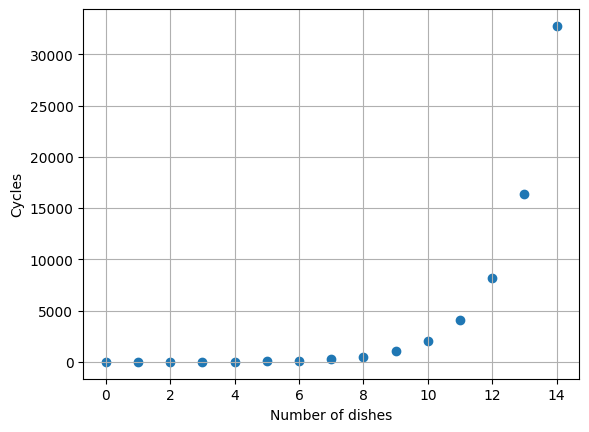

In [48]:
plt.scatter(np.asarray(range(15)), count)
plt.grid(True)
plt.xlabel('Number of dishes')
plt.ylabel('Cycles')